In [188]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from moabb.datasets import BNCI2014_001, Gao2026
import datetime

# Import custom tools
from tools.dataloading import get_motorimagery_loaders, get_raw_data, create_dataloaders
from tools.preprocessing import apply_mne_ica
from tools.training import Trainer
# from models import FusionEEGNet

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [189]:
class EEGNetBlock(nn.Module):
    """
    This module abstracts a branch of the Fusion EEGNet model.
    It follows the architecture of the original EEGNet, but with some modifications to fit the fusion model.

    Args:
    - electrode_channels (int): The number of EEG channels (electrodes) in the input data.
    - temporal_filters (int): The number of filters in the temporal convolution layer.
    - spatial_filters (int): The number of filters in the spatial convolution layer.
    - temporal_kernel_length (int): The length of the temporal convolution kernel.
    - out_channels (int): The number of output channels after the pointwise convolution, which determines the feature dimension for the classification head.
    - dropout (float, optional): The dropout rate applied after the second pooling layer to prevent overfitting. Default is 0.5.
    """

    def __init__(
        self,
        electrode_channels: int,
        temporal_filters: int,
        spatial_filters: int,
        temporal_kernel_length: int,
        out_channels: int,
        dropout: float = 0.75
    ) -> None:
        super(EEGNetBlock, self).__init__()

        self.temporal_conv = nn.Conv2d(
            in_channels=1,
            out_channels=temporal_filters,
            kernel_size=(1, temporal_kernel_length),
            padding='same',
            bias=False
        )
        self.batch_norm_temporal = nn.BatchNorm2d(temporal_filters)

        self.spatial_conv = nn.Conv2d(
            in_channels=temporal_filters,
            out_channels=spatial_filters,
            kernel_size=(electrode_channels, 1),
            groups=temporal_filters,
            bias=False
        )

        self.batch_norm_spatial = nn.BatchNorm2d(spatial_filters)

        self.elu = nn.ELU()
        self.pool1 = nn.AvgPool2d((1, 4))

        self.separable_conv = nn.Sequential(
            nn.Conv2d(
                in_channels=spatial_filters,
                out_channels=spatial_filters,
                kernel_size=(1, temporal_kernel_length * 2),
                padding='same',
                groups=spatial_filters,
                bias=False
            ),
            nn.Conv2d(
                in_channels=spatial_filters,
                out_channels=out_channels,
                kernel_size=(1, 1),
                bias=False
            )
        )

        self.batch_norm_separable = nn.BatchNorm2d(out_channels)

        self.pool2 = nn.AvgPool2d((1, 8))

        self.dropout = nn.Dropout(p=dropout)

    def output_features(self, sample_length: int) -> int:
        """
        Returns the integer number of output features produced by this block
        for a given `sample_length` (temporal length).

        Because the pooling layers use kernel sizes of 4 then 8 (with default
        stride equal to kernel size), the temporal dimension after pooling is
        reduced by a factor of 4 and then 8. When `sample_length` is not
        perfectly divisible by these factors we use floor division to compute
        the resulting temporal size.

        The final number of features equals `out_channels * floor(sample_length / 32)`.
        This method returns that integer value (suitable for feeding into a
        classifier head or for flatten size calculations).
        """

        reduction = 4 * 8
        temporal_after_pool = sample_length // reduction

        return int(self.separable_conv[-1].out_channels * temporal_after_pool)

    def forward(self, x):
        x = self.temporal_conv(x)
        x = self.batch_norm_temporal(x)
        x = self.spatial_conv(x)
        x = self.batch_norm_spatial(x)
        x = self.elu(x)
        x = self.pool1(x)
        x = self.separable_conv(x)
        x = self.batch_norm_separable(x)
        x = self.elu(x)
        x = self.pool2(x)
        x = self.dropout(x)
        return x


class FusionEEGNet(nn.Module):
    """
    This module implements the Fusion EEGNet architecture, which consists of multiple parallel branches (EEGNetBlocks) that process data in parallel with different filter configurations.
    """

    def __init__(self, n_classes: int, electrode_channels: int, sample_length: int, filters: list[tuple[int, int, int, int]]):
        """

        Args:
            n_classes (int): The number of output classes for classification.
            electrode_channels (int): The number of EEG channels (electrodes) in the input data.
            sample_length (int): The temporal length of the input data (number of time points).
            filters (list[tuple[int, int, int, int]]): A list where each tuple contains the configuration for a branch in the format (temporal_filters, spatial_filters, temporal_kernel_length, out_channels).
        """
        super(FusionEEGNet, self).__init__()

        self.branches = nn.ModuleList([
            EEGNetBlock(
                electrode_channels=electrode_channels,
                temporal_filters=temporal_filters,
                spatial_filters=spatial_filters,
                temporal_kernel_length=temporal_kernel_length,
                out_channels=out_channels
            )
            for temporal_filters, spatial_filters, temporal_kernel_length, out_channels in filters
        ])

        self.flatten = nn.Flatten()

        self.classifier = nn.Linear(
            in_features=sum(branch.output_features(sample_length)  # type: ignore
                            for branch in self.branches),
            out_features=n_classes
        )

    def forward(self, x):
        x = [branch(x) for branch in self.branches]
        x = torch.cat(x, dim=1)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [225]:
filters = [
    (8, 16, 64, 8),
    # (16, 32, 128, 16),

]


# 1. Pipeline Configuration
dataset = BNCI2014_001()

# Setting up standard industry parameters for testing a baseline
hyperparams = {
    "dataset": type(dataset).__name__,
    "split_mode": "random",
    "test_subject_id": 1,
    "batch_size": 32,
    "sample_frequency": 128,
    "learning_rate": 1e-3,
    "epochs": 300,
    "patience": 50,
    "dropout_rate": 0.75,
    "n_filters": len(filters),
    "preprocessing": "ICA",
    "n_classes": 4,
    "electrode_channels": 22,
    "sample_length": 513
}

# Add dynamic timestamp string to organize logs
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_dir = f"models/fussion_eegnet/results/baseline_{hyperparams['dataset']}_{hyperparams['split_mode']}_{timestamp}"

In [182]:
X, y, metadata = get_raw_data(
    dataset, n_subjects=-1, sample_frequency=hyperparams["sample_frequency"])

# Extract dynamic dimensions from the dataset that the model needs
hyperparams["n_classes"] = metadata["n_classes"]
hyperparams["electrode_channels"] = metadata["electrode_channels"]
hyperparams["sample_length"] = metadata["sample_length"]


X, y, metadata = apply_mne_ica(
    X, y, metadata, sfreq=hyperparams["sample_frequency"], n_components=15)

Choosing from all possible events


Applying MNE ICA (method=fastica, n_components=15) to epoched data...
Fitting ICA to data using 22 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 46.7s.
Applying ICA to Epochs instance
    Transforming to ICA space (15 components)
    Zeroing out 0 ICA components
    Projecting back using 22 PCA components


In [202]:
np.median(X, axis=(0, 2), keepdims=True).shape

(1, 22, 1)

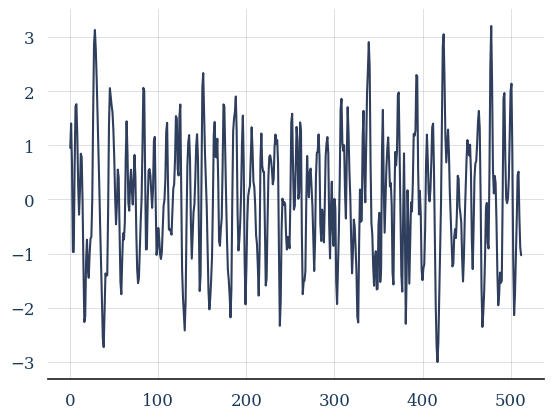

In [221]:
# Channelwise normalization techniques for comparison

def min_max_normalize(X, subjects):
    X_out = np.empty_like(X)
    unique_subjects = np.unique(subjects)

    for subj in unique_subjects:
        mask = subjects == subj
        X_subj = X[mask]

        X_min = np.min(X_subj, axis=(0, 2), keepdims=True)
        X_max = np.max(X_subj, axis=(0, 2), keepdims=True)

        X_out[mask] = (X_subj - X_min) / (X_max - X_min + 1e-8)

    return X_out


def strs_normalisation(X, subjects, n_classes: int):
    X_out = np.empty_like(X)
    unique_subjects = np.unique(subjects)

    for subj in unique_subjects:
        mask = subjects == subj
        X_subj = X[mask]

        x_abs = np.abs(X_subj)
        median = np.median(x_abs, axis=(0, 2), keepdims=True)
        q3 = np.quantile(x_abs, 0.75, axis=(0, 2), keepdims=True)

        x_centred = x_abs - median

        gamma = np.log(n_classes - 1)
        kappa = (gamma + np.log(3)) / q3

        X_out[mask] = 1 / (1 + np.exp(-(kappa * x_centred - gamma)))

    return X_out


def z_score_normalize(X, subjects):
    X_out = np.empty_like(X)
    unique_subjects = np.unique(subjects)

    for subj in unique_subjects:
        mask = subjects == subj
        X_subj = X[mask]

        mean = np.mean(X_subj, axis=(0, 2), keepdims=True)
        std = np.std(X_subj, axis=(0, 2), keepdims=True)

        X_out[mask] = (X_subj - mean) / (std + 1e-8)

    return X_out


x_norm = z_score_normalize(
    X, metadata["subject"])

plt.plot(x_norm[0, 0, :])

In [222]:
train_loader, test_loader, metadata = create_dataloaders(
    x_norm, y, metadata, split_mode=hyperparams["split_mode"], test_subject_id=hyperparams["test_subject_id"], batch_size=hyperparams["batch_size"])



Split Mode: RANDOM | Users pooled | test_size=0.2 | random_state=42
Training on 4148 trials from all selected subjects
Testing on 1036 trials from all selected subjects
Input Shape for Model: torch.Size([32, 1, 22, 513])
Batch size: 32 | Nº Channels: 22 | Sample length: 513


In [226]:
model = FusionEEGNet(
    n_classes=hyperparams["n_classes"],
    electrode_channels=hyperparams["electrode_channels"],
    sample_length=hyperparams["sample_length"],
    filters=filters,
).to(device)

torch.compile(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=hyperparams["learning_rate"])

In [227]:
# 4. Training and Evaluation Tracking
trainer = Trainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    log_dir=log_dir,
    experiment_config=hyperparams
)

trainer.train(
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=hyperparams["epochs"],
    patience=hyperparams["patience"]
)

Starting training on cuda...
Logging TensorBoard to: models/fussion_eegnet/results/baseline_BNCI2014_001_random_20260406-172557
Epoch [1/300] | Train Loss: 1.3743 | Test Loss: 1.2990 | Test Acc: 37.93%
Epoch [10/300] | Train Loss: 1.0995 | Test Loss: 1.0291 | Test Acc: 53.57%
Epoch [20/300] | Train Loss: 1.0124 | Test Loss: 0.9950 | Test Acc: 59.17%
Epoch [30/300] | Train Loss: 0.9768 | Test Loss: 0.9107 | Test Acc: 60.71%
Epoch [40/300] | Train Loss: 0.9454 | Test Loss: 0.9253 | Test Acc: 59.56%
Epoch [50/300] | Train Loss: 0.9233 | Test Loss: 0.9076 | Test Acc: 60.91%
Epoch [60/300] | Train Loss: 0.9028 | Test Loss: 0.8960 | Test Acc: 62.55%
Epoch [70/300] | Train Loss: 0.8886 | Test Loss: 0.8817 | Test Acc: 63.13%
Epoch [80/300] | Train Loss: 0.8681 | Test Loss: 0.8571 | Test Acc: 64.48%
Epoch [90/300] | Train Loss: 0.8496 | Test Loss: 0.8638 | Test Acc: 63.90%
Epoch [100/300] | Train Loss: 0.8353 | Test Loss: 0.8480 | Test Acc: 63.80%
Epoch [110/300] | Train Loss: 0.7964 | Test Los